<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2014/try_it_14_1_self_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Self-Study Try-It Activity 14.1: Generating Overfit Models

By default, you scikitlearn tree models will grow until every node is pure.  To explore this, you are to build different models using the `max_depth` parameter and determine when the tree begins to overfit the data.  For depths from `max_depth = 1` until the tree is completed, keep track of the accuracy on training vs. test data and generate a plot with depths as the horizontal axis and accuracy as the vertical axis for train and test data.  

Repeat this process with different splits of the data to determine at what depth the tree begins to overfit.  Share your results with your peers and discuss your approach to generating the visualization.  What are the consequences of this overfitting for your approach to building Decision Trees?   We provide a small dataset with health data where your goal is to predict whether or not the individuals survive.

In [222]:
import pandas as pdf
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [223]:
data = pd.read_csv('/content/sample_data/Whickham.txt')

In [224]:
data.head()

,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64


In [225]:
import warnings
warnings.filterwarnings("ignore")
X = data[['smoker', 'age']]
y = data['outcome']
y=y.map({'Alive':1, 'Dead':0})
y
X['smoker']=X['smoker'].map({"Yes":1,"No":0})

In [226]:
type(X),type(y)

(pandas.core.frame.DataFrame, pandas.core.series.Series)


To explore reaching purity that will make the tree continue to grow ,
you are to build different models using the `max_depth` parameter and determine when the tree begins to overfit the data.  
For depths from `max_depth = 1` until the tree is completed, keep track of the accuracy on training vs. test data
and generate a plot with depths as the horizontal axis and accuracy as the vertical axis for train and test data.  

In [227]:
X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2 ,random_state=42 )#stratify =X['age']

In [228]:
dtree= DecisionTreeClassifier(max_depth=3).fit(X_train,y_train)

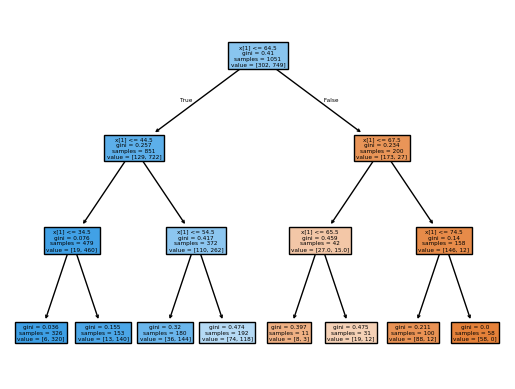

In [229]:
plot_tree(dtree, filled=True);


In [230]:
print(tree.export_text(dtree,feature_names=list(X_train.columns)))

|--- age <= 64.50
|   |--- age <= 44.50
|   |   |--- age <= 34.50
|   |   |   |--- class: 1
|   |   |--- age >  34.50
|   |   |   |--- class: 1
|   |--- age >  44.50
|   |   |--- age <= 54.50
|   |   |   |--- class: 1
|   |   |--- age >  54.50
|   |   |   |--- class: 1
|--- age >  64.50
|   |--- age <= 67.50
|   |   |--- age <= 65.50
|   |   |   |--- class: 0
|   |   |--- age >  65.50
|   |   |   |--- class: 0
|   |--- age >  67.50
|   |   |--- age <= 74.50
|   |   |   |--- class: 0
|   |   |--- age >  74.50
|   |   |   |--- class: 0



In [231]:
# Predict on the training set (depth=3)
y_train_pred = dtree.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Predict on the testing set
y_test_pred = dtree.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Compare the accuracy on the training set and the testing set
print("Accuracy on the training set:", train_accuracy)
print("Accuracy on the testing set:", test_accuracy)

Accuracy on the training set: 0.851569933396765
Accuracy on the testing set: 0.8555133079847909


In [232]:
# Try with depth=9
training_accuracies= list()
testing_accuracies= list()
for max_depth in range(1,10):
  dtree9= DecisionTreeClassifier(max_depth=max_depth).fit(X_train,y_train)# Predict on the training set (depth=9)
  y_train_pred = dtree9.predict(X_train)
  train_accuracy = accuracy_score(y_train, y_train_pred)

  # Predict on the testing set
  y_test_pred = dtree9.predict(X_test)
  test_accuracy = accuracy_score(y_test, y_test_pred)

  # Compare the accuracy on the training set and the testing set
  training_accuracies.append(train_accuracy)
  testing_accuracies.append(test_accuracy)


In [233]:
print(training_accuracies)
print(testing_accuracies)

[0.851569933396765, 0.851569933396765, 0.851569933396765, 0.851569933396765, 0.8525214081826832, 0.8610846812559467, 0.8610846812559467, 0.8610846812559467, 0.8610846812559467]
[0.8555133079847909, 0.8555133079847909, 0.8555133079847909, 0.8555133079847909, 0.8555133079847909, 0.8517110266159695, 0.8517110266159695, 0.8517110266159695, 0.844106463878327]


Repeat this process with different splits of the data to determine at what depth the tree begins to overfit.  Share your results with your peers and discuss your approach to generating the visualization.  What are the consequences of this overfitting for your approach to building Decision Trees?   We provide a small dataset with health data where your goal is to predict whether or not the individuals survive.

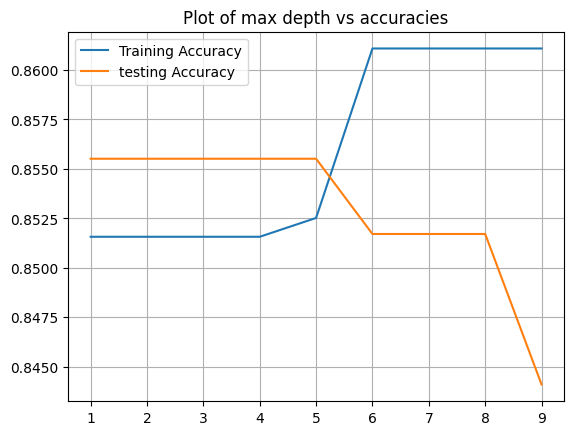

In [234]:
plt.plot(range(1,10),training_accuracies, label="Training Accuracy")
plt.plot(range(1,10),testing_accuracies, label="testing Accuracy")
plt.title("Plot of max depth vs accuracies")
plt.grid(True)
plt.legend()
plt.show()